<a href="https://colab.research.google.com/github/varchu04/smart-waste-detection/blob/main/03_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — Image Preprocessing

## Objectives
- Load waste classification images
- Resize images to a standard size
- Convert images to RGB
- Normalize pixel values
- Visualize the preprocessing result
- Verify the processed image format

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "techsash/waste-classification-data"
)

print("Dataset location:", dataset_path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset location: /kaggle/input/waste-classification-data


In [3]:
train_path = os.path.join(
    dataset_path,
    "DATASET",
    "TRAIN"
)

test_path = os.path.join(
    dataset_path,
    "DATASET",
    "TEST"
)

print("Training path:", train_path)
print("Testing path:", test_path)

print("Training exists:", os.path.exists(train_path))
print("Testing exists:", os.path.exists(test_path))

Training path: /kaggle/input/waste-classification-data/DATASET/TRAIN
Testing path: /kaggle/input/waste-classification-data/DATASET/TEST
Training exists: True
Testing exists: True


In [4]:
train_classes = sorted(os.listdir(train_path))
test_classes = sorted(os.listdir(test_path))

print("Training classes:", train_classes)
print("Testing classes:", test_classes)

Training classes: ['O', 'R']
Testing classes: ['O', 'R']


In [5]:
IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    """
    Load and preprocess a single image.

    Steps:
    1. Open image
    2. Convert to RGB
    3. Resize to 224x224
    4. Convert to NumPy array
    5. Normalize pixel values to [0, 1]
    """

    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = np.array(image, dtype=np.float32)
    image_array = image_array / 255.0

    return image_array

In [6]:
sample_class = train_classes[0]

sample_image = os.listdir(
    os.path.join(train_path, sample_class)
)[0]

sample_path = os.path.join(
    train_path,
    sample_class,
    sample_image
)

processed_image = preprocess_image(sample_path)

print("Image:", sample_image)
print("Processed shape:", processed_image.shape)
print("Data type:", processed_image.dtype)
print("Minimum value:", processed_image.min())
print("Maximum value:", processed_image.max())

Image: O_5670.jpg
Processed shape: (224, 224, 3)
Data type: float32
Minimum value: 0.0
Maximum value: 1.0


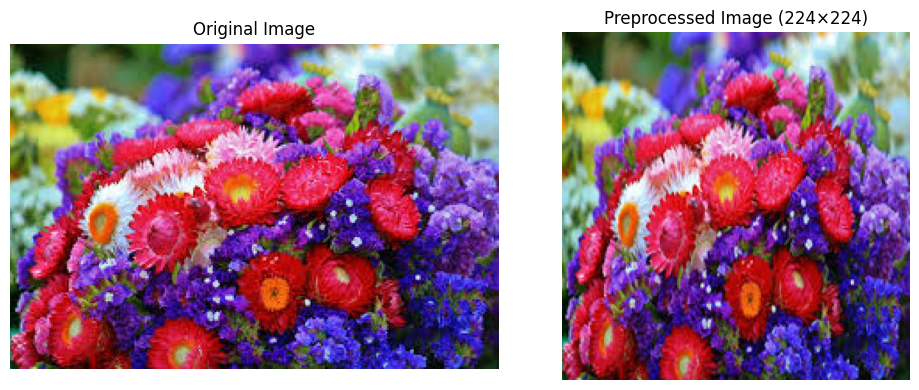

In [7]:
original_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_image)
plt.title("Preprocessed Image (224×224)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
samples = []

for class_name in train_classes:
    class_path = os.path.join(train_path, class_name)
    image_files = os.listdir(class_path)[:3]

    for image_file in image_files:
        image_path = os.path.join(class_path, image_file)
        processed = preprocess_image(image_path)

        samples.append({
            "class": class_name,
            "file": image_file,
            "shape": processed.shape,
            "min": processed.min(),
            "max": processed.max()
        })

for sample in samples:
    print(sample)

{'class': 'O', 'file': 'O_5670.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.0), 'max': np.float32(1.0)}
{'class': 'O', 'file': 'O_1764.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.0), 'max': np.float32(1.0)}
{'class': 'O', 'file': 'O_9501.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.0), 'max': np.float32(1.0)}
{'class': 'R', 'file': 'R_6214.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.003921569), 'max': np.float32(1.0)}
{'class': 'R', 'file': 'R_8141.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.0), 'max': np.float32(1.0)}
{'class': 'R', 'file': 'R_2463.jpg', 'shape': (224, 224, 3), 'min': np.float32(0.0), 'max': np.float32(1.0)}


In [11]:
classes = train_classes

print(classes)

['O', 'R']


In [12]:
sample_count = 5

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    image_files = os.listdir(class_path)[:sample_count]

    print(f"\nClass: {class_name}")
    print(f"Testing {len(image_files)} images")

    for file_name in image_files:
        file_path = os.path.join(class_path, file_name)

        processed = preprocess_image(file_path)

        print(
            file_name,
            "→",
            processed.shape,
            "→ range:",
            f"{processed.min():.4f} - {processed.max():.4f}"
        )


Class: O
Testing 5 images
O_5670.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
O_1764.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
O_9501.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
O_364.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
O_5301.jpg → (224, 224, 3) → range: 0.0000 - 1.0000

Class: R
Testing 5 images
R_6214.jpg → (224, 224, 3) → range: 0.0039 - 1.0000
R_8141.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
R_2463.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
R_9892.jpg → (224, 224, 3) → range: 0.0000 - 1.0000
R_5469.jpg → (224, 224, 3) → range: 0.0000 - 1.0000


## Preprocessing Validation Summary

The preprocessing pipeline was successfully validated on 10 sample images.

- 5 Organic (O) images
- 5 Recyclable (R) images
- Images resized to 224 × 224
- Pixel values normalized to 0–1